In [7]:
pip install numpy matplotlib keras

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

In [9]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [10]:
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images (28x28 → 784)
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print("New shape:", X_train.shape)

New shape: (60000, 784)


In [11]:
def one_hot(y):
    onehot = np.zeros((y.size, 10))
    onehot[np.arange(y.size), y] = 1
    return onehot

y_train = one_hot(y_train)
y_test = one_hot(y_test)

print("Label shape:", y_train.shape)

Label shape: (60000, 10)


In [12]:
# Network sizes
input_size = 784
hidden_size = 256
output_size = 10

lr = 0.1
epochs = 30

# Initialize weights
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

In [13]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return x > 0

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [14]:
batch_size = 64
epochs = 30
lr = 0.1

m = X_train.shape[0]

for epoch in range(epochs):

    # shuffle dataset
    perm = np.random.permutation(m)
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]

    for i in range(0, m, batch_size):

        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        # forward
        z1 = np.dot(X_batch, W1) + b1
        a1 = relu(z1)

        z2 = np.dot(a1, W2) + b2
        a2 = softmax(z2)

        # loss gradient
        dz2 = a2 - y_batch

        dW2 = np.dot(a1.T, dz2) / batch_size
        db2 = np.sum(dz2, axis=0, keepdims=True) / batch_size

        dz1 = np.dot(dz2, W2.T) * relu_derivative(z1)

        dW1 = np.dot(X_batch.T, dz1) / batch_size
        db1 = np.sum(dz1, axis=0, keepdims=True) / batch_size

        # update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    # compute training accuracy
    z1 = np.dot(X_train, W1) + b1
    a1 = relu(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = softmax(z2)

    preds = np.argmax(a2, axis=1)
    labels = np.argmax(y_train, axis=1)

    train_acc = np.mean(preds == labels)

    print(f"Epoch {epoch+1} | Train Accuracy: {train_acc:.4f}")

Epoch 1 | Train Accuracy: 0.9187
Epoch 2 | Train Accuracy: 0.9470
Epoch 3 | Train Accuracy: 0.9585
Epoch 4 | Train Accuracy: 0.9646
Epoch 5 | Train Accuracy: 0.9706
Epoch 6 | Train Accuracy: 0.9740
Epoch 7 | Train Accuracy: 0.9777
Epoch 8 | Train Accuracy: 0.9812
Epoch 9 | Train Accuracy: 0.9843
Epoch 10 | Train Accuracy: 0.9855
Epoch 11 | Train Accuracy: 0.9870
Epoch 12 | Train Accuracy: 0.9890
Epoch 13 | Train Accuracy: 0.9900
Epoch 14 | Train Accuracy: 0.9909
Epoch 15 | Train Accuracy: 0.9916
Epoch 16 | Train Accuracy: 0.9926
Epoch 17 | Train Accuracy: 0.9942
Epoch 18 | Train Accuracy: 0.9946
Epoch 19 | Train Accuracy: 0.9959
Epoch 20 | Train Accuracy: 0.9960
Epoch 21 | Train Accuracy: 0.9965
Epoch 22 | Train Accuracy: 0.9973
Epoch 23 | Train Accuracy: 0.9971
Epoch 24 | Train Accuracy: 0.9979
Epoch 25 | Train Accuracy: 0.9981
Epoch 26 | Train Accuracy: 0.9984
Epoch 27 | Train Accuracy: 0.9988
Epoch 28 | Train Accuracy: 0.9986
Epoch 29 | Train Accuracy: 0.9989
Epoch 30 | Train Accura

In [15]:
z1 = np.dot(X_test, W1) + b1
a1 = relu(z1)

z2 = np.dot(a1, W2) + b2
a2 = softmax(z2)

predictions = np.argmax(a2, axis=1)
labels = np.argmax(y_test, axis=1)

accuracy = np.mean(predictions == labels)

print("Final Test Accuracy:", accuracy)

Final Test Accuracy: 0.9808


In [16]:
z1 = np.dot(X_test, W1) + b1
a1 = relu(z1)

z2 = np.dot(a1, W2) + b2
a2 = softmax(z2)

predictions = np.argmax(a2, axis=1)
labels = np.argmax(y_test, axis=1)

accuracy = np.mean(predictions == labels)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9808


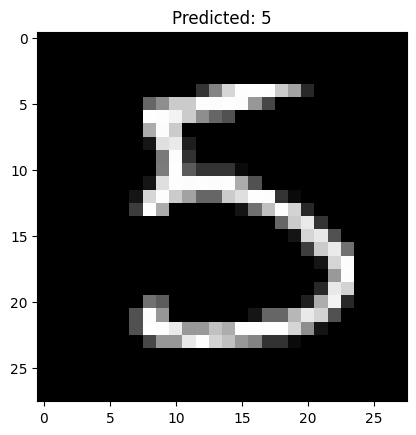

In [17]:
index = 15

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predictions[index]}")
plt.show()

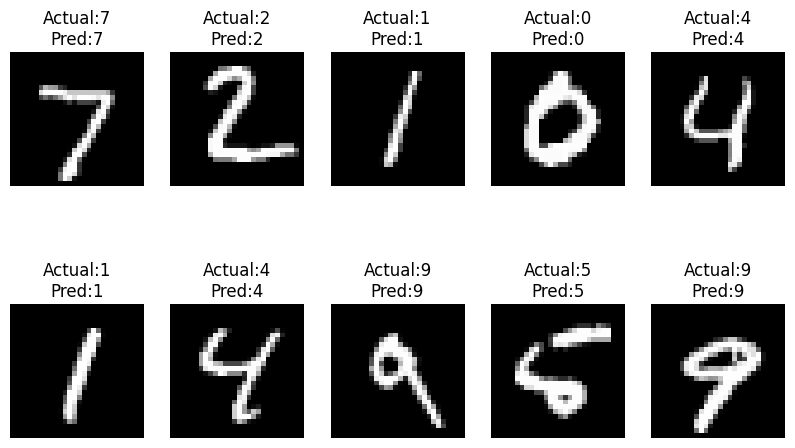

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i in range(10):
    
    plt.subplot(2,5,i+1)
    
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    
    plt.title(f"Actual:{labels[i]}\nPred:{predictions[i]}")
    
    plt.axis('off')

plt.show()

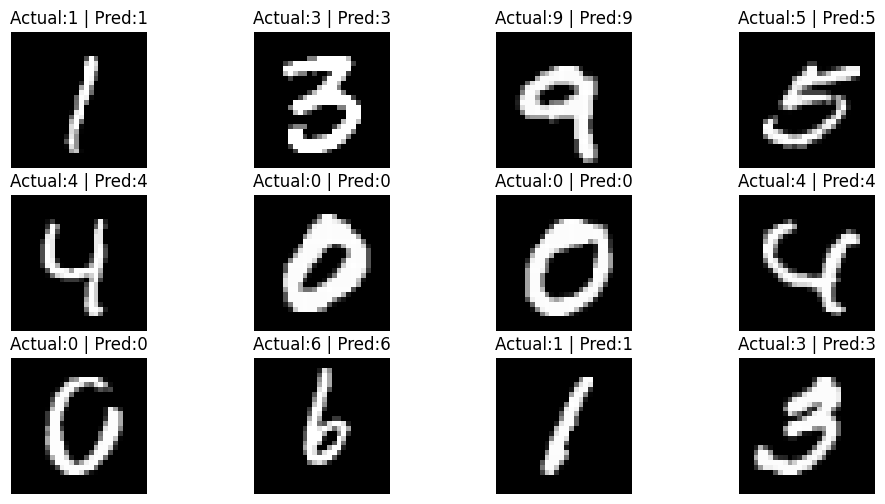

In [19]:
import random

plt.figure(figsize=(12,6))

for i in range(12):
    
    idx = random.randint(0,9999)
    
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    
    plt.title(f"Actual:{labels[idx]} | Pred:{predictions[idx]}")
    plt.axis('off')

plt.show()

In [20]:
for i in range(10):
    print("Image",i,"Actual:",labels[i],"Predicted:",predictions[i])

Image 0 Actual: 7 Predicted: 7
Image 1 Actual: 2 Predicted: 2
Image 2 Actual: 1 Predicted: 1
Image 3 Actual: 0 Predicted: 0
Image 4 Actual: 4 Predicted: 4
Image 5 Actual: 1 Predicted: 1
Image 6 Actual: 4 Predicted: 4
Image 7 Actual: 9 Predicted: 9
Image 8 Actual: 5 Predicted: 5
Image 9 Actual: 9 Predicted: 9


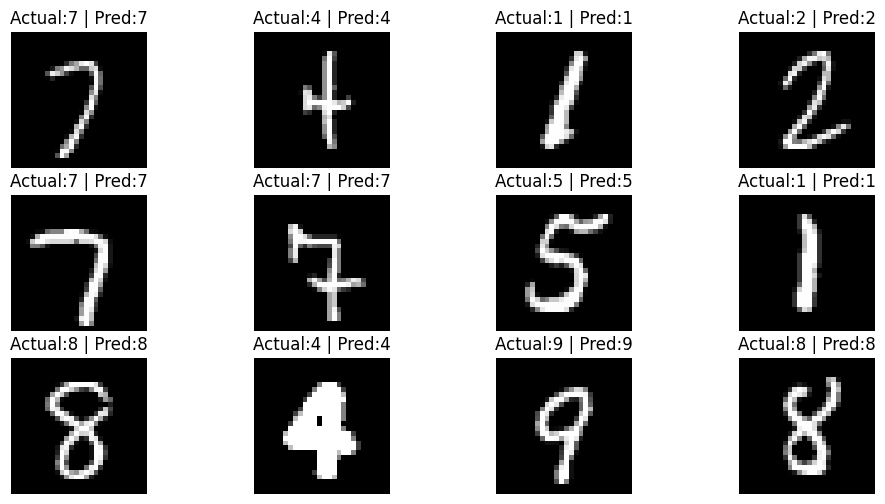

In [21]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12,6))

for i in range(12):

    idx = random.randint(0,9999)

    plt.subplot(3,4,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')

    plt.title(f"Actual:{labels[idx]} | Pred:{predictions[idx]}")
    plt.axis("off")

plt.show()

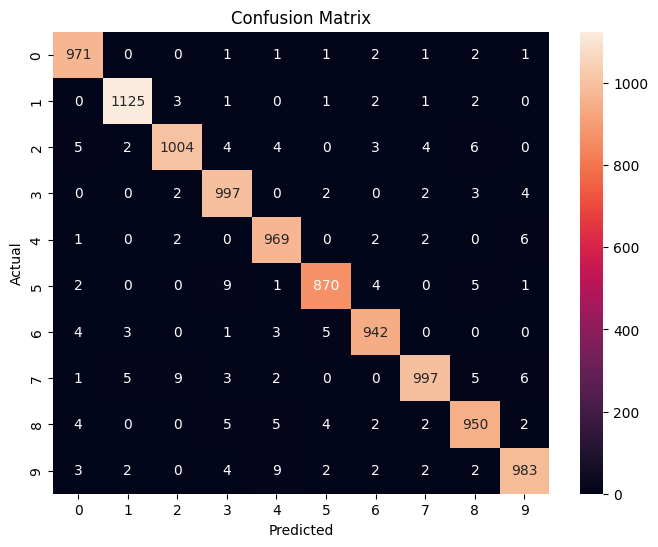

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(labels, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()